Extracting parameters from Data/Test2\FD_.5sponge_4-11-2025.vhdr...
Setting channel info structure...
Reading 0 ... 1129899  =      0.000 ...  1129.899 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB

C:\Users\mhfar\AppData\Local\Temp\ipykernel_7192\2766073192.py:65: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psd = data_obj.compute_psd(fmax=fmax, method='multitaper')



⚡ Band Power (total across all channels):
- Delta (0.5–4 Hz): 0.00164482
- Theta (4–8 Hz): 0.00020650
- Alpha (8–12 Hz): 0.00011260
- Beta (12–30 Hz): 0.00016643
- Gamma (30–50 Hz): 0.00005193

📊 Relative Band Power (%):
- Delta (0.5–4 Hz): 75.37%
- Theta (4–8 Hz): 9.46%
- Alpha (8–12 Hz): 5.16%
- Beta (12–30 Hz): 7.63%
- Gamma (30–50 Hz): 2.38%

📶 SNR Metrics:
- Alpha/Gamma SNR: 2.17
- Alpha/Beta SNR: 0.68

========== VEP ANALYSIS WITH ARTIFACT REJECTION ==========

🔍 Found 1 potential VEP triggers: ['Stimulus/S  7']

🔍 Evaluating VEP response for trigger: Stimulus/S  7
Not setting metadata
310 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 310 events and 601 original time points ...
    Rejecting  epoch based on EEG : ['11']
    Rejecting  epoch based on EEG : ['11']
    Rejecting  epoch based on EEG : ['11']
    Rejecting  epoch based on EEG : ['11']
    

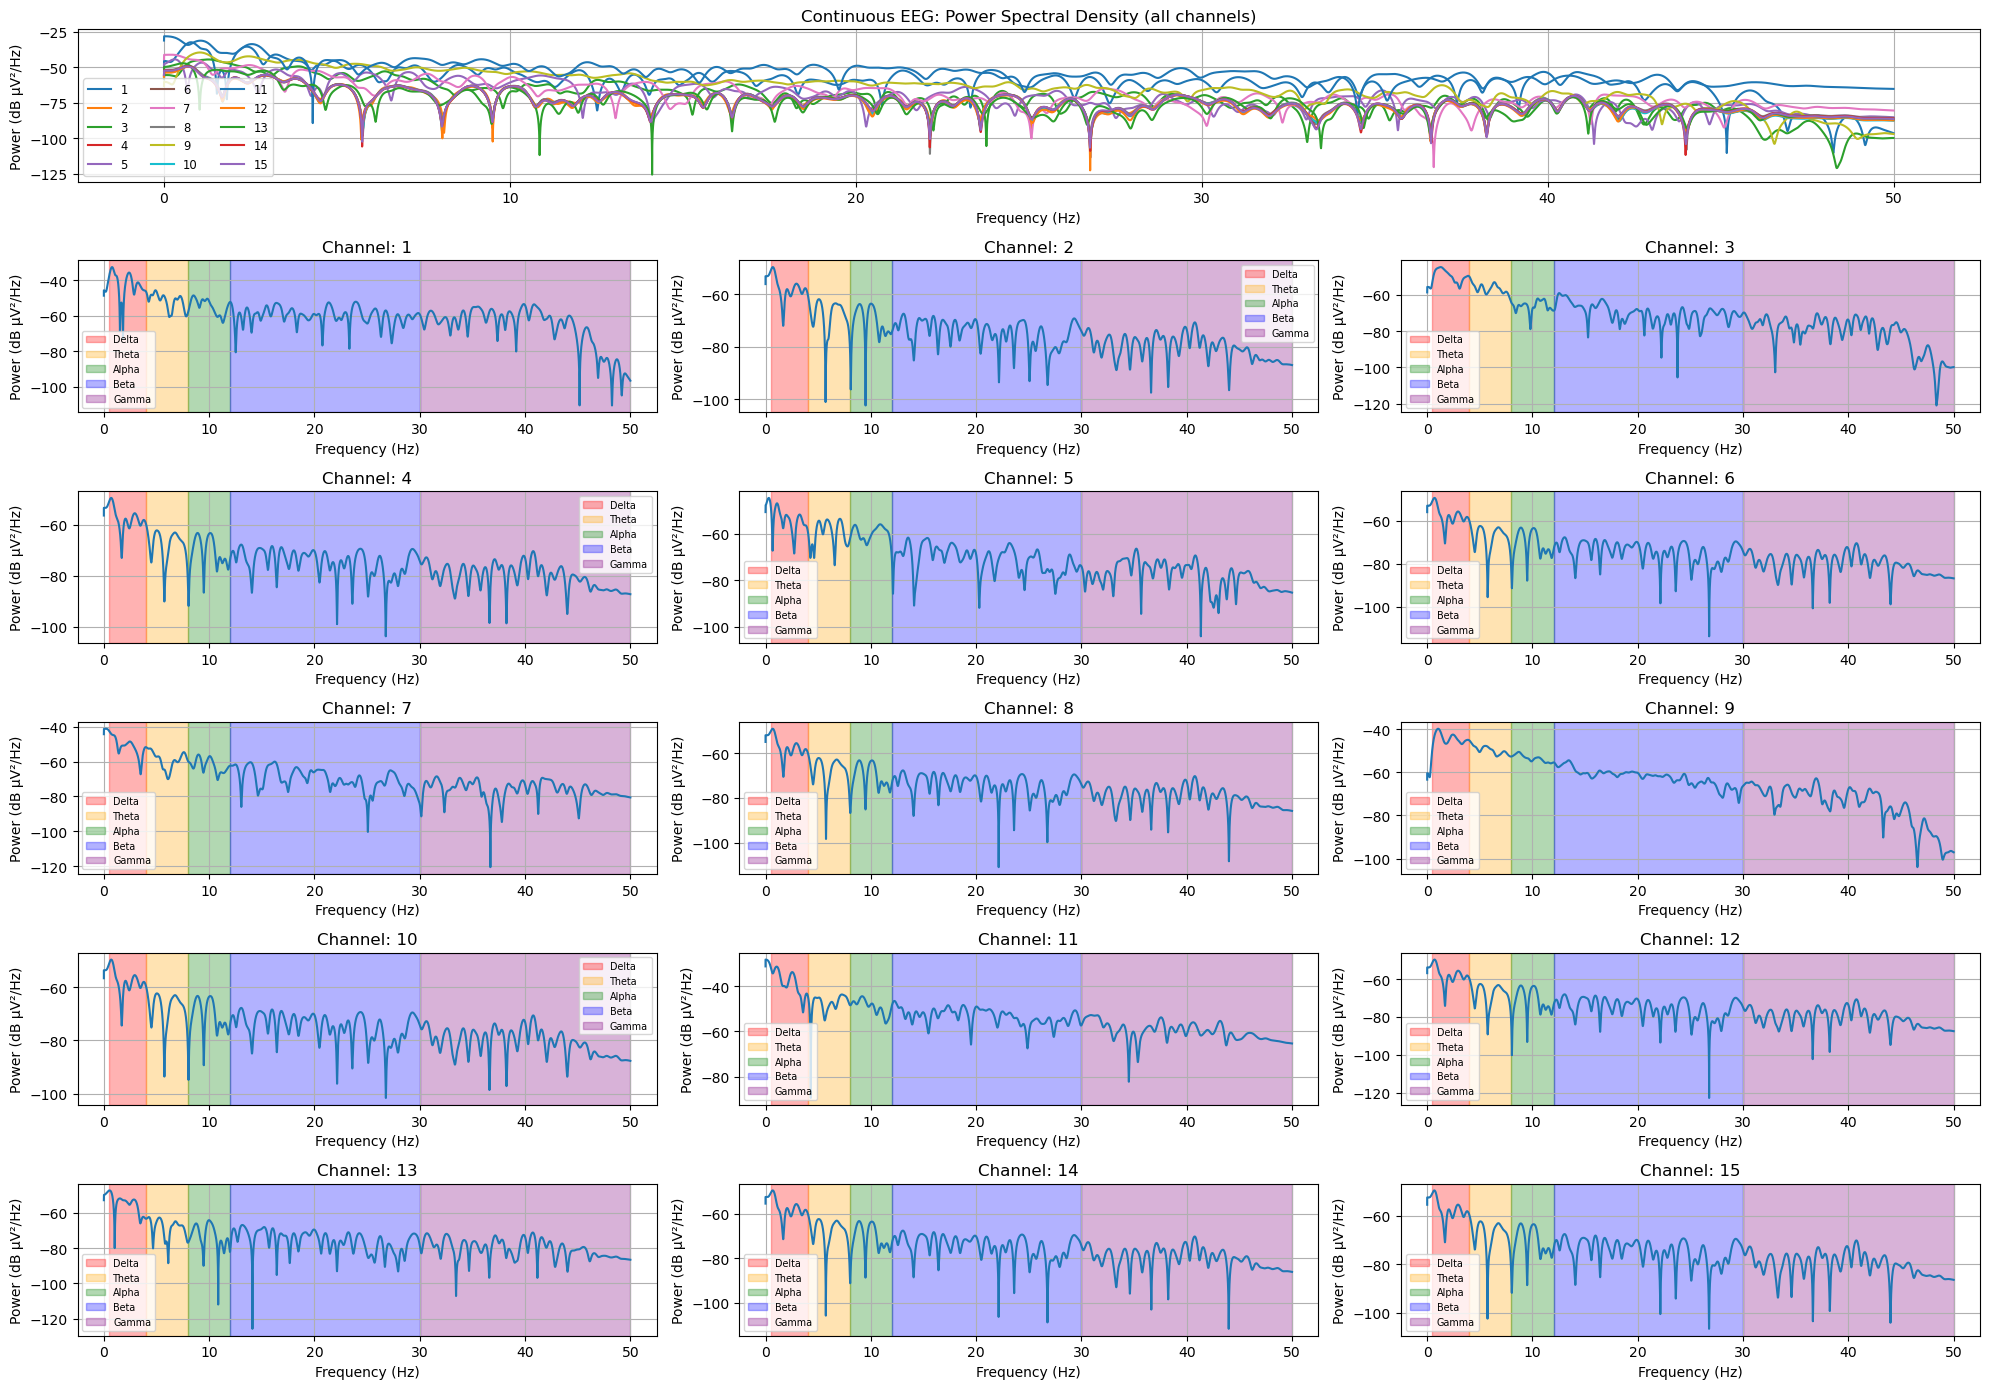

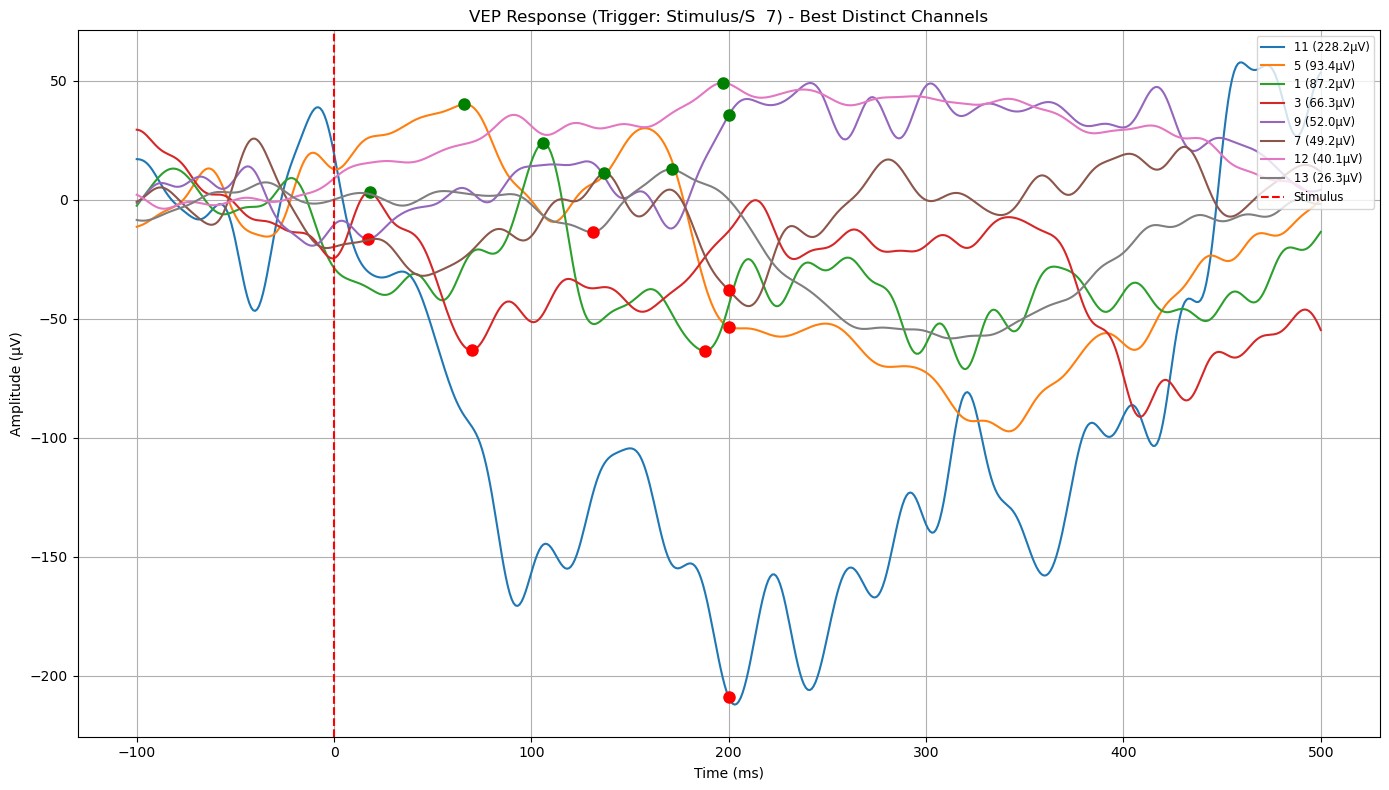

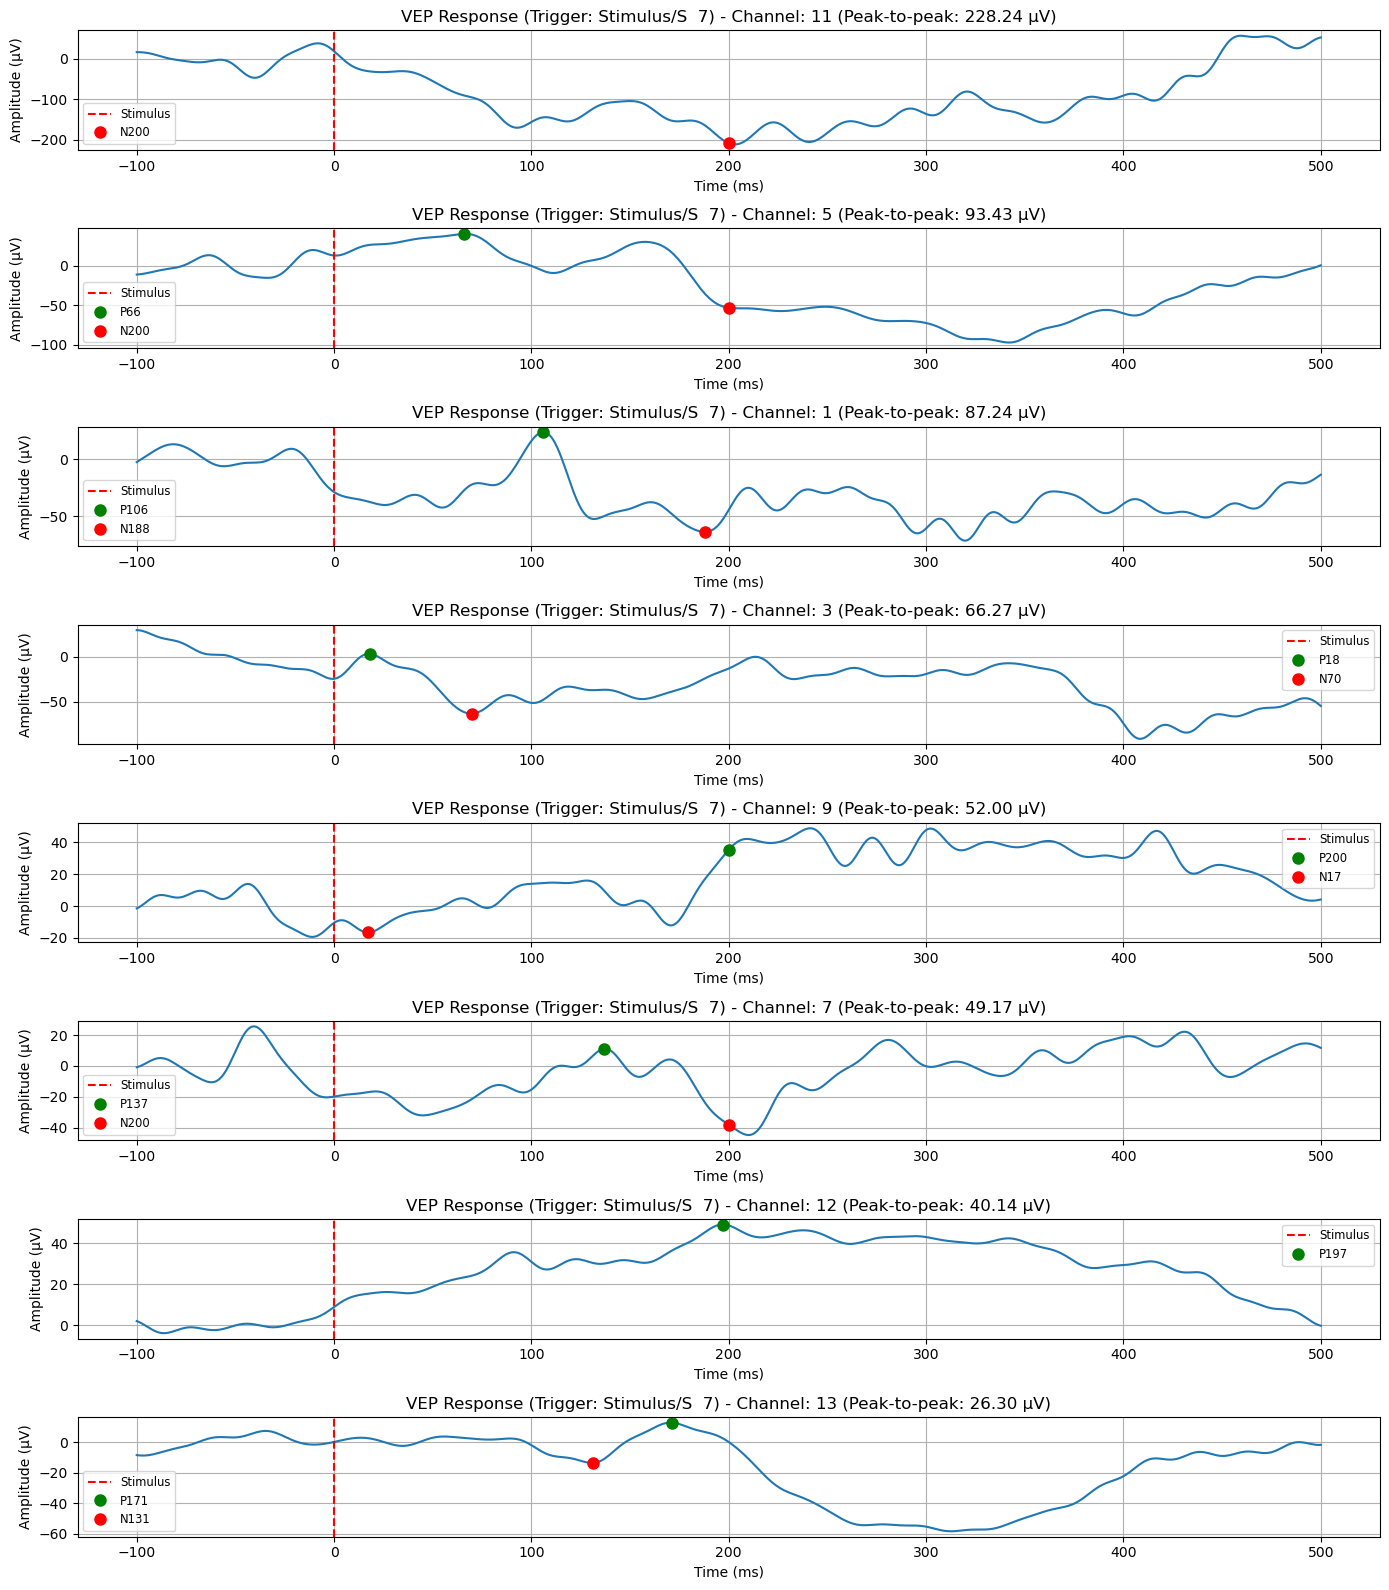

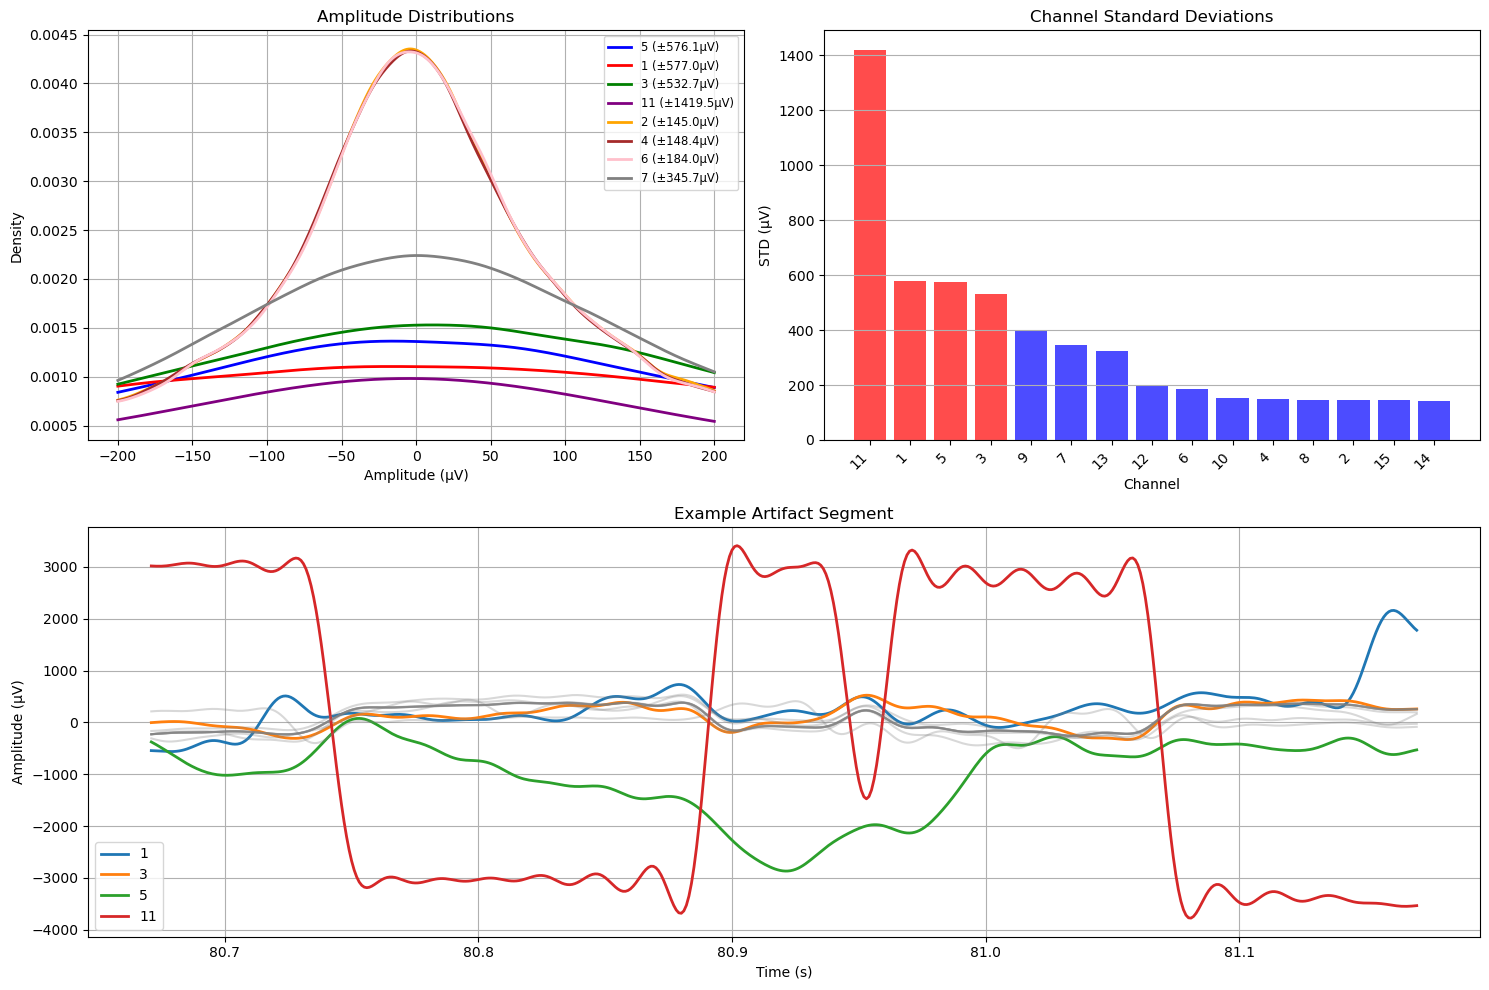

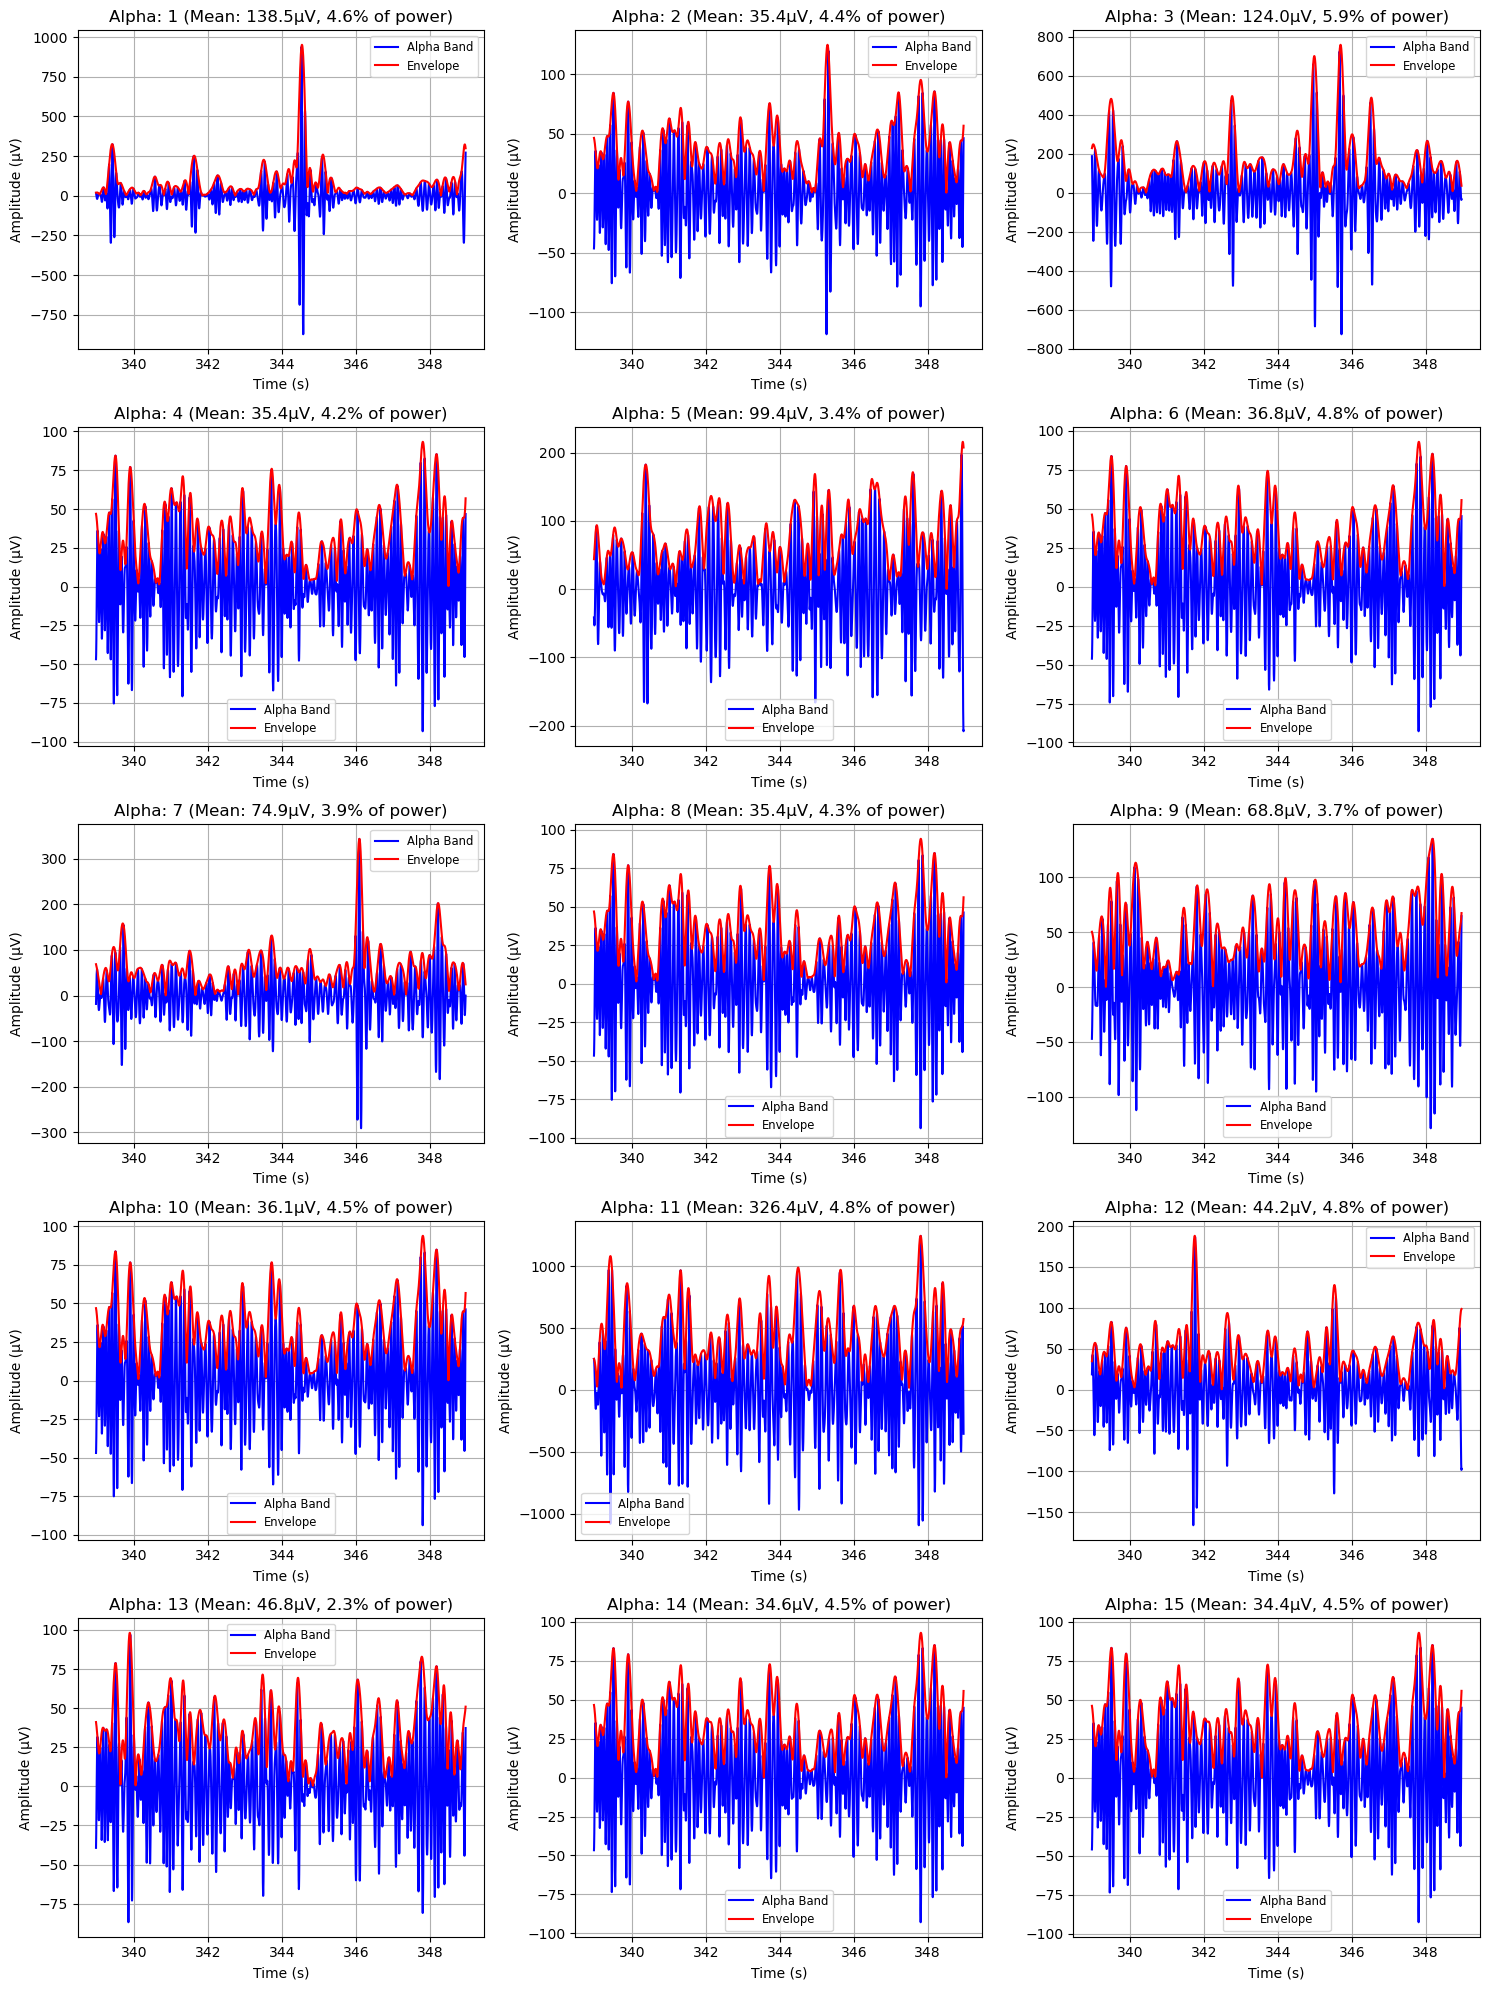

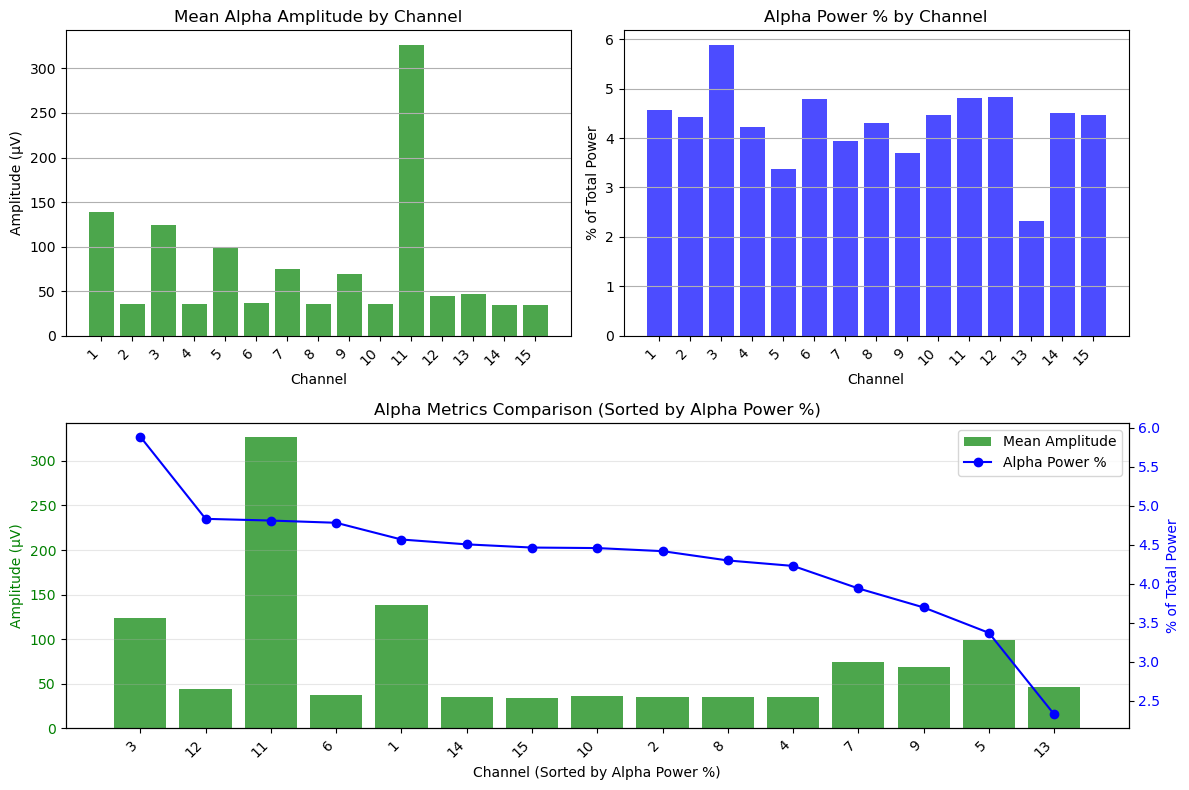

In [7]:
# -----------------------------
# File Setup and Loading
# -----------------------------
base_dir = r"Data/Test2"
#base_fname = "PF_feltTCRE_VEP_BrainAmp_5-5-2025"
#base_fname = "NS_feltTCRE_BrainAmp_5-2-2025"
base_fname = "FD_.5sponge_4-11-2025"
#base_fname = "FD_sponge1"

import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps
from matplotlib.gridspec import GridSpec
import os
import pandas as pd
import scipy.signal
from scipy import stats  # Added for KDE plots

# Load main EEG file
vhdr_file = os.path.join(base_dir, f"{base_fname}.vhdr")
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)


raw.filter(l_freq=1., h_freq=40., fir_design='firwin',
           skip_by_annotation='edge')          # 1‑40 Hz band‑pass
raw.notch_filter(freqs=[60, 120])              # kill mains hum
raw.set_eeg_reference('average', projection=True)
raw.apply_proj()
# Find and load trigger events from marker file
events_from_annot, event_dict = mne.events_from_annotations(raw)
print(f"\n🔄 Found {len(events_from_annot)} events with {len(event_dict)} unique event types")
print(f"Event dictionary: {event_dict}")

# -----------------------------
# Basic EEG Info
# -----------------------------
n_channels = len(raw.ch_names)
duration_sec = raw.times[-1]
sfreq = raw.info['sfreq']
print(f"\n✅ EEG Info:")
print(f"- Channels: {n_channels}")
print(f"- Channel names: {raw.ch_names}")
print(f"- Duration: {duration_sec:.2f} sec")
print(f"- Sampling Rate: {sfreq} Hz")

# -----------------------------
# Global Amplitude / Noise
# -----------------------------
data = raw.get_data()
std = data.std()
print(f"\n📏 Global Signal STD (µV): {std * 1e6:.4f}")

# -----------------------------
# PSD Computation and Visualization
# -----------------------------
def compute_and_visualize_psd(data_obj, title_prefix="", fmax=50):
    """Compute PSD and create visualization for the input data"""
    # Check if the input is Raw or Epochs object and compute PSD accordingly
    if isinstance(data_obj, mne.io.Raw):
        # For Raw objects, use n_fft parameter
        psd = data_obj.compute_psd(fmax=fmax, n_fft=int(sfreq * 4))
    else:
        # For Epochs objects, use appropriate parameters for multitaper method
        psd = data_obj.compute_psd(fmax=fmax, method='multitaper')
    
    psds, freqs = psd.get_data(return_freqs=True)
    psds_db = 10 * np.log10(psds)
    
    # Compute band powers
    band_powers, band_relative_powers = compute_band_powers(psds, freqs)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 14))
    
    # Determine how many channel plots we need
    ch_count = len(data_obj.ch_names)
    
    # Create a flexible grid layout
    # 1 row for main plot, then rows for individual channels (3 per row)
    # Calculate how many rows needed for channel plots
    channels_per_row = 3
    channel_rows = (ch_count + channels_per_row - 1) // channels_per_row
    total_rows = 1 + channel_rows  # Main plot + channel rows
    
    # Create GridSpec with proper dimensions
    gs = GridSpec(total_rows, channels_per_row, figure=fig)
    
    # 1. Main PSD plot (all channels)
    ax1 = fig.add_subplot(gs[0, :])
    for i, ch in enumerate(data_obj.ch_names):
        ax1.plot(freqs, psds_db[i], label=ch)
    ax1.set_title(f"{title_prefix}Power Spectral Density (all channels)")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Power (dB µV²/Hz)")
    ax1.legend(fontsize='small', ncol=3)
    ax1.grid(True)
    
    # 2. Individual channel PSD plots
    for i, ch in enumerate(data_obj.ch_names):
        row = 1 + (i // channels_per_row)
        col = i % channels_per_row
        
        ax = fig.add_subplot(gs[row, col])
        ax.plot(freqs, psds_db[i])
        ax.set_title(f"Channel: {ch}")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power (dB µV²/Hz)")
        ax.axvspan(0.5, 4, color='red', alpha=0.3, label='Delta')
        ax.axvspan(4, 8, color='orange', alpha=0.3, label='Theta')
        ax.axvspan(8, 12, color='green', alpha=0.3, label='Alpha')
        ax.axvspan(12, 30, color='blue', alpha=0.3, label='Beta')
        ax.axvspan(30, 50, color='purple', alpha=0.3, label='Gamma')
        ax.legend(fontsize='x-small')
        ax.grid(True)
    
    plt.tight_layout()
    return fig, band_powers, band_relative_powers, psds, freqs

# -----------------------------
# Band Power Estimation
# -----------------------------
def compute_band_powers(psds, freqs):
    """Compute absolute and relative power in standard frequency bands"""
    def bandpower(data, freqs, band):
        idx = np.logical_and(freqs >= band[0], freqs <= band[1])
        # For each channel, calculate band power using Simpson's rule
        powers = np.zeros(data.shape[0])
        for i in range(data.shape[0]):
            powers[i] = simps(data[i, idx], freqs[idx])
        # Return the sum across all channels
        return float(np.sum(powers))  # Convert to float to avoid numpy formatting issues
    
    bands = {
        'Delta (0.5–4 Hz)': (0.5, 4),
        'Theta (4–8 Hz)': (4, 8),
        'Alpha (8–12 Hz)': (8, 12),
        'Beta (12–30 Hz)': (12, 30),
        'Gamma (30–50 Hz)': (30, 50)
    }
    
    # Calculate absolute power for each band
    band_powers = {}
    for label, band_range in bands.items():
        band_powers[label] = bandpower(psds, freqs, band_range)
    
    # Calculate total power across all bands
    total_power = sum(band_powers.values())
    
    # Calculate relative power (percentage of total)
    band_relative_powers = {}
    for label in bands.keys():
        band_relative_powers[label] = (band_powers[label] / total_power) * 100
    
    print(f"\n⚡ Band Power (total across all channels):")
    for label, power in band_powers.items():
        print(f"- {label}: {power:.8f}")
    
    print(f"\n📊 Relative Band Power (%):")
    for label, rel_power in band_relative_powers.items():
        print(f"- {label}: {rel_power:.2f}%")
    
    # SNR calculations
    snr_alpha_gamma = band_powers['Alpha (8–12 Hz)'] / band_powers['Gamma (30–50 Hz)']
    snr_alpha_beta = band_powers['Alpha (8–12 Hz)'] / band_powers['Beta (12–30 Hz)']
    print(f"\n📶 SNR Metrics:")
    print(f"- Alpha/Gamma SNR: {snr_alpha_gamma:.2f}")
    print(f"- Alpha/Beta SNR: {snr_alpha_beta:.2f}")
    
    return band_powers, band_relative_powers

# -----------------------------
# Plot Raw Data Segment
# -----------------------------
def plot_raw_segment(raw_data, duration=0.5, random=True, start_time=None):
    """Plot a segment of raw EEG data"""
    ch_count = len(raw_data.ch_names)
    data, times = raw_data[:ch_count, :]
    win = int(sfreq * duration)
    
    if random:
        start = np.random.randint(0, data.shape[1] - win)
    else:
        start = int(start_time * sfreq) if start_time is not None else 0
    
    seg = data[:, start:start+win]
    seg_time = times[start:start+win]
    
    # Dynamic offset based on signal amplitude
    max_amp = np.max(np.abs(seg)) * 1e6
    offset = max(100, max_amp * 1.5) * 1e-6  # Adjusted offset for better visualization
    
    plt.figure(figsize=(15, 8))
    for i in range(ch_count):
        plt.plot(seg_time, seg[i] * 1e6 + i * offset * 1e6, label=raw_data.ch_names[i])
    
    plt.title(f"Raw EEG ({duration}s segment {'random' if random else f'at {start_time}s'})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    
    return plt.gcf()

# -----------------------------
# Epoch Data with Artifact Rejection
# -----------------------------
def create_clean_epochs(raw, events, event_id, tmin=-0.2, tmax=0.5, reject_threshold_mv=5):
    """Create epochs from raw data and reject artifacts above threshold"""
    
    # Set rejection threshold (converting from mV to V)
    reject_criteria = dict(eeg=reject_threshold_mv * 1e-3)  # 5 mV converted to V
    
    # Create epochs with rejection
    epochs = mne.Epochs(raw, events, event_id, tmin=tmin, tmax=tmax,
                        baseline=(tmin, 0), reject=reject_criteria,
                        preload=True, verbose=True)
    
    # Get information about dropped epochs
    drop_log = epochs.drop_log
    total_epochs = len(events)
    kept_epochs = len(epochs)
    dropped_epochs = total_epochs - kept_epochs
    drop_percent = (dropped_epochs / total_epochs) * 100 if total_epochs > 0 else 0
    
    print(f"\n🧹 Artifact Rejection:")
    print(f"- Total epochs: {total_epochs}")
    print(f"- Kept epochs: {kept_epochs}")
    print(f"- Rejected epochs: {dropped_epochs} ({drop_percent:.1f}%)")
    
    # Identify which channels had the most artifacts
    if dropped_epochs > 0:
        channel_drops = {}
        for ch in raw.ch_names:
            channel_drops[ch] = 0
        
        for log in drop_log:
            if log and len(log) > 0:
                for reason in log:
                    if reason != 'eeg' and reason in raw.ch_names:
                        channel_drops[reason] = channel_drops.get(reason, 0) + 1
        
        print("- Rejection count by channel:")
        for ch, count in channel_drops.items():
            if count > 0:
                print(f"  * {ch}: {count} epochs")
        
        # Additional analysis of problem channels
        if channel_drops:
            problem_channels = sorted(
                [(ch, count) for ch, count in channel_drops.items() if count > 0],
                key=lambda x: x[1], reverse=True
            )
            if problem_channels:
                worst_ch, worst_count = problem_channels[0]
                worst_percent = (worst_count / total_epochs) * 100
                print(f"\n⚠️ Channel Quality Alert:")
                print(f"- Most problematic channel: {worst_ch} with {worst_count} rejected epochs ({worst_percent:.1f}%)")
                
                # Get some data about the worst channel
                ch_idx = raw.ch_names.index(worst_ch)
                ch_data = raw.get_data()[ch_idx] * 1e6  # Convert to µV
                ch_std = np.std(ch_data)
                ch_max = np.max(np.abs(ch_data))
                print(f"- Channel '{worst_ch}' stats: Max amplitude: {ch_max:.2f} µV, STD: {ch_std:.2f} µV")
    
    return epochs

# -----------------------------
# Compute and Visualize Evoked Response
# -----------------------------
def process_vep_response(epochs, title="Visual Evoked Potential", min_peak_amplitude=1.0, max_channels=None):
    """
    Compute average evoked response and visualize it, focusing only on distinct channels
    with good signal quality
    
    Parameters:
    -----------
    epochs : mne.Epochs
        Epochs object containing the data
    title : str
        Title for the plots
    min_peak_amplitude : float
        Minimum peak-to-peak amplitude (in µV) for a channel to be considered as having good signal
    max_channels : int
        Maximum number of individual channels to highlight (selects the best ones based on signal quality)
        If None, will use all channels
    """
    # Calculate evoked response (average across epochs)
    evoked = epochs.average()
    
    times = evoked.times * 1000  # Convert to milliseconds
    data = evoked.data * 1e6  # Convert to µV
    
    # Calculate signal quality metrics for each channel
    channel_metrics = []
    
    for i, ch in enumerate(evoked.ch_names):
        # Get post-stimulus data (0-200ms)
        post_stim = np.where((times >= 0) & (times <= 200))[0]
        if len(post_stim) > 0:
            ch_data = data[i, post_stim]
            
            # Calculate peak-to-peak amplitude
            peak_amp = np.max(ch_data)
            trough_amp = np.min(ch_data)
            peak_to_peak = peak_amp - trough_amp
            
            # Get peak and trough indices and times
            peak_idx = np.argmax(ch_data) + post_stim[0]
            trough_idx = np.argmin(ch_data) + post_stim[0]
            peak_time = times[peak_idx]
            trough_time = times[trough_idx]
            
            # Calculate signal-to-noise ratio
            # Use pre-stimulus period as baseline noise estimate
            baseline = np.where((times >= -100) & (times < 0))[0]
            if len(baseline) > 0:
                baseline_std = np.std(data[i, baseline])
                snr = peak_to_peak / (baseline_std * 2) if baseline_std > 0 else 0
            else:
                snr = 0
            
            # Calculate latency to first peak (useful for distinguishing patterns)
            first_peak_latency = peak_time if peak_time < trough_time else trough_time
                
            channel_metrics.append({
                'index': i,
                'name': ch,
                'peak_to_peak': peak_to_peak,
                'snr': snr,
                'peak_time': peak_time,
                'trough_time': trough_time,
                'peak_idx': peak_idx,
                'trough_idx': trough_idx,
                'peak_amp': peak_amp,
                'trough_amp': trough_amp,
                'first_peak_latency': first_peak_latency
            })
    
    # Sort channels by peak-to-peak amplitude
    channel_metrics.sort(key=lambda x: x['peak_to_peak'], reverse=True)
    
    # Select channels with good signal (above minimum amplitude)
    good_channels = [ch for ch in channel_metrics if ch['peak_to_peak'] >= min_peak_amplitude]
    
    # If max_channels is specified, limit the number of good channels
    if max_channels is not None and len(good_channels) > max_channels:
        good_channels = good_channels[:max_channels]
    
    # If no good channels found, include at least the top channel
    if not good_channels and channel_metrics:
        good_channels = [channel_metrics[0]]
    
    # Print the selected channels
    ch_count = len(good_channels)
    print(f"\n📊 Selected {ch_count} channels with good VEP signal:")
    for ch in good_channels:
        print(f"- {ch['name']}: Peak-to-peak amplitude: {ch['peak_to_peak']:.2f} µV, SNR: {ch['snr']:.2f}")
    
    # Filter out similar channels to keep only distinct response patterns
    distinct_channels = []
    if good_channels:
        # Always include the best channel
        distinct_channels.append(good_channels[0])
        
        # For each remaining channel, check if it's distinct from already selected channels
        for ch in good_channels[1:]:
            is_distinct = True
            for selected_ch in distinct_channels:
                # Calculate correlation between the current channel and selected channels
                i1, i2 = ch['index'], selected_ch['index']
                # Only use post-stimulus data for comparison
                post_stim_indices = np.where((times >= 0) & (times <= 200))[0]
                corr = np.corrcoef(data[i1, post_stim_indices], data[i2, post_stim_indices])[0, 1]
                
                # Also check if peak/trough timings are very similar
                timing_diff = abs(ch['peak_time'] - selected_ch['peak_time']) + abs(ch['trough_time'] - selected_ch['trough_time'])
                
                # If correlation is high and timings are similar, consider it similar to an existing channel
                if corr > 0.85 and timing_diff < 15:
                    is_distinct = False
                    break
            
            if is_distinct:
                distinct_channels.append(ch)
        
        # If we removed too many, ensure at least 3 diverse channels are shown (if available)
        if len(distinct_channels) < min(3, len(good_channels)):
            # Add more channels, prioritizing the highest amplitude ones
            for ch in good_channels:
                if ch not in distinct_channels and len(distinct_channels) < min(3, len(good_channels)):
                    distinct_channels.append(ch)
    
    print(f"\n🔍 Selected {len(distinct_channels)} distinct channels for visualization")
    
    # Create only a single figure showing the best channels
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111)
    
    # Plot best individual channels
    for ch_metric in distinct_channels:
        i = ch_metric['index']
        ch = ch_metric['name']
        
        ax.plot(times, data[i], label=f"{ch} ({ch_metric['peak_to_peak']:.1f}µV)")
        
        # Mark the peak and trough
        peak_time = ch_metric['peak_time']
        trough_time = ch_metric['trough_time']
        peak_idx = ch_metric['peak_idx']
        trough_idx = ch_metric['trough_idx']
        
        # Mark the peak
        if peak_time > 0:
            ax.plot(peak_time, data[i, peak_idx], 'go', markersize=8)
        
        # Mark the trough
        if trough_time > 0:
            ax.plot(trough_time, data[i, trough_idx], 'ro', markersize=8)
    
    ax.set_title(f"{title} - Best Distinct Channels")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.axvline(x=0, color='r', linestyle='--', label='Stimulus')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')
    
    plt.tight_layout()
    
    # ADDED: Create a detailed view of individual good channels
    if distinct_channels:
        # Create a separate figure for individual channel plots (limited to distinct channels)
        detail_fig = plt.figure(figsize=(14, min(4 * len(distinct_channels), 16)))
        detail_gs = GridSpec(len(distinct_channels), 1, figure=detail_fig)
        
        for idx, ch_metric in enumerate(distinct_channels):
            i = ch_metric['index']
            ch = ch_metric['name']
            
            ax = detail_fig.add_subplot(detail_gs[idx])
            ax.plot(times, data[i])
            ax.set_title(f"{title} - Channel: {ch} (Peak-to-peak: {ch_metric['peak_to_peak']:.2f} µV)")
            ax.set_xlabel("Time (ms)")
            ax.set_ylabel("Amplitude (µV)")
            ax.axvline(x=0, color='r', linestyle='--', label='Stimulus')
            
            # Mark the peak and trough
            peak_time = ch_metric['peak_time']
            trough_time = ch_metric['trough_time']
            peak_idx = ch_metric['peak_idx']
            trough_idx = ch_metric['trough_idx']
            
            # Mark the peak
            if peak_time > 0:
                ax.plot(peak_time, data[i, peak_idx], 'go', markersize=8, 
                      label=f'P{peak_time:.0f}')
            
            # Mark the trough
            if trough_time > 0:
                ax.plot(trough_time, data[i, trough_idx], 'ro', markersize=8, 
                      label=f'N{trough_time:.0f}')
            
            ax.legend(fontsize='small')
            ax.grid(True)
        
        plt.tight_layout()
        return fig, detail_fig, evoked
    
    return fig, None, evoked

# -----------------------------
# Alpha Wave Analysis
# -----------------------------
def analyze_alpha_waves(raw):
    """Analyze alpha wave characteristics in the data"""
    # Filter data to alpha band (8-12 Hz)
    raw_alpha = raw.copy().filter(8, 12)
    
    # Get data
    alpha_data = raw_alpha.get_data() * 1e6  # convert to µV
    
    # Calculate alpha amplitude envelope using Hilbert transform
    alpha_envelope = np.abs(scipy.signal.hilbert(alpha_data, axis=1))
    
    # Calculate metrics
    alpha_mean = np.mean(alpha_envelope, axis=1)
    alpha_std = np.std(alpha_envelope, axis=1)
    alpha_max = np.max(alpha_envelope, axis=1)
    
    # Create visualization with horizontal arrangement for better space usage
    ch_count = len(raw.ch_names)
    
    # Calculate grid dimensions
    cols = min(3, ch_count)
    rows = (ch_count + cols - 1) // cols
    
    fig = plt.figure(figsize=(5*cols, 4*rows))
    gs = GridSpec(rows, cols, figure=fig)
    
    # Create alpha metrics table
    metrics_df = pd.DataFrame({
        'Channel': raw.ch_names,
        'Mean Amplitude (µV)': alpha_mean,
        'Max Amplitude (µV)': alpha_max,
        'Std Dev (µV)': alpha_std,
    })
    
    # Additional metrics: alpha power ratio
    # Compute proportion of alpha to total power
    psd = raw.compute_psd(fmax=50)
    psds, freqs = psd.get_data(return_freqs=True)
    
    alpha_ratios = []
    
    for ch_idx in range(len(raw.ch_names)):
        # Get alpha band indices
        alpha_idx = np.logical_and(freqs >= 8, freqs <= 12)
        alpha_power = simps(psds[ch_idx, alpha_idx], freqs[alpha_idx])
        
        # Get total power (0.5-50 Hz)
        total_idx = np.logical_and(freqs >= 0.5, freqs <= 50)
        total_power = simps(psds[ch_idx, total_idx], freqs[total_idx])
        
        # Calculate ratio
        alpha_ratio = (alpha_power / total_power) * 100
        alpha_ratios.append(alpha_ratio)
    
    # Add to dataframe
    metrics_df['Alpha Power (%)'] = alpha_ratios
    
    # Sort channels by alpha power ratio for analysis
    sorted_metrics = metrics_df.sort_values(by='Alpha Power (%)', ascending=False)
    
    print("\n🧠 Alpha Wave Metrics (Sorted by Alpha Power %):")
    print(sorted_metrics.to_string(index=False))
    
    # Plot alpha waves and envelopes
    for i, ch in enumerate(raw.ch_names):
        row = i // cols
        col = i % cols
        
        ax = fig.add_subplot(gs[row, col])
        
        # Plot 10 seconds of alpha signal and its envelope
        t_start = int(raw.times.shape[0] * 0.3)  # Start at 30% into recording
        segment_len = min(int(10 * sfreq), len(raw.times) - t_start)  # Handle case where recording is short
        t_end = t_start + segment_len
        
        t_plot = raw.times[t_start:t_end]
        ax.plot(t_plot, alpha_data[i, t_start:t_end], 'b', label='Alpha Band')
        ax.plot(t_plot, alpha_envelope[i, t_start:t_end], 'r', label='Envelope')
        
        # Add alpha metrics to the title
        ch_alpha_ratio = metrics_df.loc[metrics_df['Channel'] == ch, 'Alpha Power (%)'].values[0]
        ax.set_title(f"Alpha: {ch} (Mean: {alpha_mean[i]:.1f}µV, {ch_alpha_ratio:.1f}% of power)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(fontsize='small')
        ax.grid(True)
    
    plt.tight_layout()
    
    # Create a detailed alpha summary figure
    summary_fig = plt.figure(figsize=(12, 8))
    summary_gs = GridSpec(2, 2, figure=summary_fig)
    
    # 1. Bar chart of mean alpha amplitudes
    ax1 = summary_fig.add_subplot(summary_gs[0, 0])
    ax1.bar(raw.ch_names, alpha_mean, color='green', alpha=0.7)
    ax1.set_title('Mean Alpha Amplitude by Channel')
    ax1.set_xlabel('Channel')
    ax1.set_ylabel('Amplitude (µV)')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.grid(True, axis='y')
    
    # 2. Bar chart of alpha power percentages
    ax2 = summary_fig.add_subplot(summary_gs[0, 1])
    ax2.bar(raw.ch_names, alpha_ratios, color='blue', alpha=0.7)
    ax2.set_title('Alpha Power % by Channel')
    ax2.set_xlabel('Channel')
    ax2.set_ylabel('% of Total Power')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.grid(True, axis='y')
    
    # 3. Topographic-style plot (simplified version)
    ax3 = summary_fig.add_subplot(summary_gs[1, :])
    # Create a horizontal plot showing channel comparisons
    sorted_idx = np.argsort(alpha_ratios)[::-1]  # Sort by alpha ratio descending
    ch_names_sorted = [raw.ch_names[i] for i in sorted_idx]
    alpha_mean_sorted = [alpha_mean[i] for i in sorted_idx]
    alpha_ratios_sorted = [alpha_ratios[i] for i in sorted_idx]
    
    # Plot bars with dual y-axis
    bars = ax3.bar(ch_names_sorted, alpha_mean_sorted, color='green', alpha=0.7, label='Mean Amplitude')
    ax3.set_xlabel('Channel (Sorted by Alpha Power %)')
    ax3.set_ylabel('Amplitude (µV)', color='green')
    ax3.tick_params(axis='y', labelcolor='green')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
    
    # Second y-axis for alpha ratios
    ax3b = ax3.twinx()
    ax3b.plot(ch_names_sorted, alpha_ratios_sorted, 'bo-', label='Alpha Power %')
    ax3b.set_ylabel('% of Total Power', color='blue')
    ax3b.tick_params(axis='y', labelcolor='blue')
    
    # Add title and grid
    ax3.set_title('Alpha Metrics Comparison (Sorted by Alpha Power %)')
    ax3.grid(True, axis='y', alpha=0.3)
    
    # Add combined legend
    lines, labels = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3b.get_legend_handles_labels()
    ax3b.legend(lines + lines2, labels + labels2, loc='upper right')
    
    plt.tight_layout()
    
    return fig, summary_fig, sorted_metrics

# -----------------------------
# Additional Analyses for Artifact Identification
# -----------------------------
def analyze_problematic_channels(raw, problem_channels=None):
    """Analyze channels with high artifact rates to identify issues"""
    if not problem_channels:
        # If no specific channels provided, analyze all
        problem_channels = raw.ch_names
    
    # Create figure for analysis
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, figure=fig)
    
    # 1. Amplitude distributions - FIXED with KDE plots to avoid overlap
    ax1 = fig.add_subplot(gs[0, 0])
    data = raw.get_data() * 1e6  # µV
    
    # Get all channels for visualization (up to 8 maximum)
    all_channels = raw.ch_names
    max_channels_to_show = 8  # Show a maximum of 8 channels for readability
    
    if len(all_channels) > max_channels_to_show:
        # Always include problem channels first (limited to half of max)
        problem_ch_to_include = list(problem_channels)[:max_channels_to_show//2]
        
        # Add non-problem channels to fill the rest
        channels_to_show = problem_ch_to_include.copy()
        for ch in all_channels:
            if ch not in channels_to_show and len(channels_to_show) < max_channels_to_show:
                channels_to_show.append(ch)
    else:
        channels_to_show = all_channels
    
    # Custom colors for better differentiation
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    # Use KDE plots with better binning for amplitude distributions
    for i, ch in enumerate(channels_to_show):
        ch_idx = raw.ch_names.index(ch)
        ch_data = data[ch_idx]
        
        # Better KDE calculation with appropriate bandwidth
        # Remove extreme outliers for better visualization
        # Calculate 1st and 99th percentiles to remove extreme outliers
        p1 = np.percentile(ch_data, 1)
        p99 = np.percentile(ch_data, 99)
        
        # Filter data to remove extreme outliers
        filtered_data = ch_data[(ch_data >= p1) & (ch_data <= p99)]
        
        # Create KDE with Scott's rule for bandwidth selection (better for normal-like data)
        try:
            kde = stats.gaussian_kde(filtered_data, bw_method='scott')
            
            # Create a reasonable range based on the data
            x_min = max(p1 * 1.2, -200)  # Limit the range to avoid extreme values
            x_max = min(p99 * 1.2, 200)
            x_range = np.linspace(x_min, x_max, 1000)
            
            # Plot with solid lines and good colors
            color = colors[i % len(colors)]
            ax1.plot(x_range, kde(x_range), color=color, linewidth=2, 
                    label=f"{ch} (±{np.std(ch_data):.1f}µV)")
        except:
            # Fallback if KDE fails
            print(f"KDE failed for channel {ch}, using histogram instead")
            ax1.hist(filtered_data, bins=50, alpha=0.3, density=True, color=colors[i % len(colors)], label=ch)
    
    ax1.set_title('Amplitude Distributions')
    ax1.set_xlabel('Amplitude (µV)')
    ax1.set_ylabel('Density')
    ax1.legend(fontsize='small')
    ax1.grid(True)
    
    # 2. Standard deviations
    ax2 = fig.add_subplot(gs[0, 1])
    stds = np.std(data, axis=1)
    
    # Sort channels by std
    std_order = np.argsort(stds)[::-1]
    sorted_chs = [raw.ch_names[i] for i in std_order]
    sorted_stds = [stds[i] for i in std_order]
    
    # Color bars based on whether they're in problem_channels
    colors = ['red' if ch in problem_channels else 'blue' for ch in sorted_chs]
    
    ax2.bar(sorted_chs, sorted_stds, color=colors, alpha=0.7)
    ax2.set_title('Channel Standard Deviations')
    ax2.set_xlabel('Channel')
    ax2.set_ylabel('STD (µV)')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.grid(True, axis='y')
    
    # 3. Artifact examples
    ax3 = fig.add_subplot(gs[1, :])
    
    # Find segments with high amplitude in problem channels
    artifact_samples = []
    channel_indices = [raw.ch_names.index(ch) for ch in problem_channels if ch in raw.ch_names]
    
    # Define threshold as 4 standard deviations
    thresholds = [4 * np.std(data[i]) for i in channel_indices]
    
    # Find segments where any problem channel exceeds its threshold
    for i, ch_idx in enumerate(channel_indices):
        # Find where channel exceeds threshold
        threshold = thresholds[i]
        exceeds = np.where(np.abs(data[ch_idx]) > threshold)[0]
        
        if len(exceeds) > 0:
            # Find segments (continuous blocks of samples)
            diffs = np.diff(exceeds)
            break_points = np.where(diffs > 1)[0] + 1
            segments = np.split(exceeds, break_points)
            
            # Take the middle sample of each segment
            for segment in segments:
                if len(segment) > 0:
                    middle = segment[len(segment) // 2]
                    artifact_samples.append(middle)
    
    # Plot a sample artifact if found
    if artifact_samples:
        # Use the first artifact found
        center = artifact_samples[0]
        window = int(sfreq * 0.5)  # 0.5 second window
        start = max(0, center - window//2)
        end = min(data.shape[1], center + window//2)
        
        t = raw.times[start:end]
        
        # Plot all channels with problem channels highlighted
        for i, ch in enumerate(raw.ch_names):
            if ch in problem_channels:
                ax3.plot(t, data[i, start:end], linewidth=2, label=ch)
            else:
                ax3.plot(t, data[i, start:end], 'gray', alpha=0.3)
        
        ax3.set_title('Example Artifact Segment')
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Amplitude (µV)')
        ax3.legend()
        ax3.grid(True)
    else:
        ax3.text(0.5, 0.5, 'No clear artifacts detected with current threshold',
                horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    return fig

# -----------------------------
# NEW: Function to evaluate VEP quality for each trigger
# -----------------------------
def evaluate_trigger_vep_quality(raw, events, event_id, tmin=-0.1, tmax=0.5, reject_threshold_mv=5):
    """
    Evaluate the quality of VEP response for a specific trigger.
    Returns a quality score based on peak-to-peak amplitude of the best channels.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw data
    events : array
        Events array from mne.events_from_annotations
    event_id : dict
        Event ID dictionary for the specific trigger
    tmin, tmax : float
        Time window for epochs
    reject_threshold_mv : float
        Threshold for artifact rejection in millivolts
        
    Returns:
    --------
    quality_score : float
        Quality score (average peak-to-peak amplitude of top 3 channels)
    epochs : mne.Epochs
        Epochs created for this trigger (or None if no valid epochs)
    """
    try:
        # Create epochs for this trigger
        epochs = create_clean_epochs(raw, events, event_id, tmin=tmin, tmax=tmax, 
                                    reject_threshold_mv=reject_threshold_mv)
        
        if len(epochs) == 0:
            print(f"No valid epochs for trigger {list(event_id.keys())[0]}")
            return 0, None
        
        # Calculate evoked response
        evoked = epochs.average()
        times = evoked.times * 1000  # Convert to ms
        data = evoked.data * 1e6  # Convert to µV
        
        # Get quality metrics for each channel
        channel_scores = []
        post_stim = np.where((times >= 0) & (times <= 200))[0]
        
        for i in range(len(evoked.ch_names)):
            if len(post_stim) > 0:
                ch_data = data[i, post_stim]
                peak_to_peak = np.max(ch_data) - np.min(ch_data)
                channel_scores.append(peak_to_peak)
        
        if not channel_scores:
            return 0, epochs
        
        # Sort scores and get average of top 3 (or fewer if < 3 channels)
        channel_scores.sort(reverse=True)
        top_n = min(3, len(channel_scores))
        quality_score = np.mean(channel_scores[:top_n])
        
        # Calculate number of good channels (peak-to-peak > 1.0 µV)
        good_channel_count = sum(1 for score in channel_scores if score > 1.0)
        
        print(f"Trigger {list(event_id.keys())[0]} quality score: {quality_score:.2f} µV (top {top_n} channels)")
        print(f"Number of good channels: {good_channel_count}/{len(channel_scores)}")
        
        return quality_score, epochs
    
    except Exception as e:
        print(f"Error evaluating trigger {list(event_id.keys())[0]}: {e}")
        return 0, None

# -----------------------------
# MAIN ANALYSIS PIPELINE
# -----------------------------

try:
    # 1. Run continuous data analysis
    print("\n========== CONTINUOUS EEG ANALYSIS ==========")
    
    # Skip plotting raw segment as requested
    # raw_fig = plot_raw_segment(raw, duration=1.0)  # Commented out to skip raw EEG plot

    # Compute PSD and band powers for continuous data
    psd_fig, band_powers, band_rel_powers, psds_data, freqs_data = compute_and_visualize_psd(raw, "Continuous EEG: ")

    # 2. Process VEP epochs with artifact rejection
    print("\n========== VEP ANALYSIS WITH ARTIFACT REJECTION ==========")

    # Look specifically for visual stimulus triggers (likely to start with 'S')
    # Using 'Stimulus/' prefix based on the event dictionary seen in the output
    trigger_keys = [key for key in event_dict.keys() if 'Stimulus/' in key]
    
    if trigger_keys:
        print(f"\n🔍 Found {len(trigger_keys)} potential VEP triggers: {trigger_keys}")
        
        # Process all triggers and find the one with the best VEP response
        best_trigger = None
        best_score = 0
        best_epochs = None
        
        for trigger in trigger_keys:
            trigger_id = {trigger: event_dict[trigger]}
            print(f"\n🔍 Evaluating VEP response for trigger: {trigger}")
            
            # Evaluate this trigger's VEP quality
            quality_score, epochs = evaluate_trigger_vep_quality(
                raw, events_from_annot, trigger_id, tmin=-0.1, tmax=0.5, reject_threshold_mv=5
            )
            
            if quality_score > best_score and epochs is not None and len(epochs) > 0:
                best_score = quality_score
                best_trigger = trigger
                best_epochs = epochs
                
        if best_trigger and best_epochs:
            print(f"\n✅ Selected best trigger: {best_trigger} with quality score: {best_score:.2f} µV")
            selected_trigger = best_trigger
            vep_epochs = best_epochs
            
            # Calculate and plot evoked response with only distinct channels
            evoked_fig, detail_fig, evoked_data = process_vep_response(
                vep_epochs, title=f"VEP Response (Trigger: {selected_trigger})", 
                min_peak_amplitude=1.0, max_channels=None
            )
            
            # Get problem channels from epochs
            drop_log = vep_epochs.drop_log
            problem_channels = set()
            for log in drop_log:
                if log and len(log) > 0:
                    for reason in log:
                        if reason != 'eeg' and reason in raw.ch_names:
                            problem_channels.add(reason)
            
            # Analyze problematic channels if any were identified
            if problem_channels:
                artifact_fig = analyze_problematic_channels(raw, problem_channels)
            
            # Compute PSD for the epochs - using specific method for epochs
            try:
                epochs_psd_fig, epochs_powers, epochs_rel_powers, _, _ = compute_and_visualize_psd(
                    vep_epochs, title_prefix="Epoched Data: "
                )
                
                # Compare the signal quality between continuous and epoched data
                print("\n📊 Signal Quality Comparison (Continuous vs. Clean Epochs):")
                for band in band_powers.keys():
                    cont_power = band_powers[band]
                    epoch_power = epochs_powers[band]
                    rel_change = ((epoch_power - cont_power) / cont_power) * 100
                    print(f"- {band}: {rel_change:.2f}% change after artifact rejection")
            except Exception as e:
                print(f"Could not compute PSD for epochs: {e}")
        else:
            print("⚠️ No suitable VEP response found for any trigger.")
    else:
        print("⚠️ No suitable triggers found in the data.")

    # 3. Alpha wave analysis
    print("\n========== ALPHA WAVE ANALYSIS ==========")
    alpha_fig, alpha_summary_fig, alpha_metrics = analyze_alpha_waves(raw)

    # 4. Save all figures (excluding raw_segment as requested)
    figures_to_save = {
        # "raw_segment": raw_fig,  # Removed as requested
        "continuous_psd": psd_fig,
        "alpha_waves": alpha_fig,
        "alpha_summary": alpha_summary_fig
    }

    if 'vep_epochs' in locals() and len(vep_epochs) > 0:
        figures_to_save.update({
            "vep_evoked": evoked_fig
        })
        
        if 'detail_fig' in locals() and detail_fig is not None:
            figures_to_save["vep_detail"] = detail_fig
            
        if 'epochs_psd_fig' in locals():
            figures_to_save["epochs_psd"] = epochs_psd_fig
            
        if 'artifact_fig' in locals():
            figures_to_save["artifact_analysis"] = artifact_fig

    # Save figures
    for name, fig in figures_to_save.items():
        fig.savefig(os.path.join(base_dir, f"{base_fname}_{name}.png"), dpi=300)

    # Show all figures
    plt.show()
    
except Exception as e:
    import traceback
    print(f"Error occurred: {e}")
    print(traceback.format_exc())